# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:1. **Sumber Dataset**:     Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

## Dataset yang Digunakan: **German Credit Data (Statlog)**Dataset yang digunakan pada eksperimen ini adalah **Statlog (German Credit Data)** yang dipublikasikan oleh UCI Machine Learning Repository (Hofmann, 1994). Dataset ini berisi data nasabah bank di Jerman yang akan diklasifikasikan sebagai **kredit baik (good credit risk)** atau **kredit buruk (bad credit risk)**, sehingga sangat relevan untuk studi kasus *credit scoring* pada Mlflow Tracking yang akan dibangun pada kriteria selanjutnya.**Informasi Dataset:**- Jumlah baris (instances): 1000- Jumlah kolom (fitur): 20 fitur + 1 target (`credit_risk`)- Tipe data: campuran kategorikal dan numerik- Target: `credit_risk` -> 0 = Good (kredit baik), 1 = Bad (kredit buruk)- Sumber: UCI ML Repository (https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data), diunduh melalui mirror GitHub `jbrownlee/Datasets`**Deskripsi singkat fitur:**| Kolom | Keterangan ||---|---|| checking_account_status | Status rekening giro nasabah || duration_months | Lama durasi kredit (bulan) || credit_history | Riwayat kredit nasabah || purpose | Tujuan pengajuan kredit || credit_amount | Jumlah kredit yang diajukan || savings_account | Status tabungan nasabah || employment_since | Lama masa kerja nasabah || installment_rate_pct | Persentase cicilan terhadap pendapatan || personal_status_sex | Status personal dan jenis kelamin || other_debtors | Ada/tidaknya penjamin lain || present_residence_since | Lama tinggal di alamat saat ini || property | Kepemilikan properti || age | Usia nasabah || other_installment_plans | Rencana cicilan lain || housing | Status tempat tinggal || existing_credits | Jumlah kredit yang sudah dimiliki di bank ini || job | Jenis pekerjaan || people_liable | Jumlah orang yang ditanggung || telephone | Kepemilikan telepon || foreign_worker | Status pekerja asing || **credit_risk** | **Target**: 0 = Good, 1 = Bad |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Library dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Seluruh library berhasil diimpor.")

Seluruh library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset German Credit Data
# File german_credit_data_raw.csv berada pada folder yang sama dengan notebook ini
# (lihat folder Membangun_model pada struktur submission)

df = pd.read_csv("german_credit_data_raw.csv")

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical/other credits existing,radio/television,1169,unknown/none,>= 7 years,4,male:single,none,4,real estate,67,none,own,2,skilled employee/official,1,yes,yes,0
1,0-200 DM,48,existing credits paid duly,radio/television,5951,< 100 DM,1-4 years,2,female:divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,1
2,no checking account,12,critical/other credits existing,education,2096,< 100 DM,4-7 years,2,male:single,none,3,real estate,49,none,own,1,unskilled-resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male:single,guarantor,4,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male:single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,1


In [3]:
# Mengecek tipe data dan informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_since         1000 non-null   str  
 7   installment_rate_pct     1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence_since  1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [4]:
# Mengecek statistik deskriptif untuk kolom numerik
df.describe()

,duration_months,credit_amount,installment_rate_pct,present_residence_since,age,existing_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# 4.1 Mengecek missing values
print("Jumlah missing values per kolom:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Jumlah missing values per kolom:
checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate_pct       0
personal_status_sex        0
other_debtors              0
present_residence_since    0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Total missing values: 0


In [6]:
# 4.2 Mengecek data duplikat
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


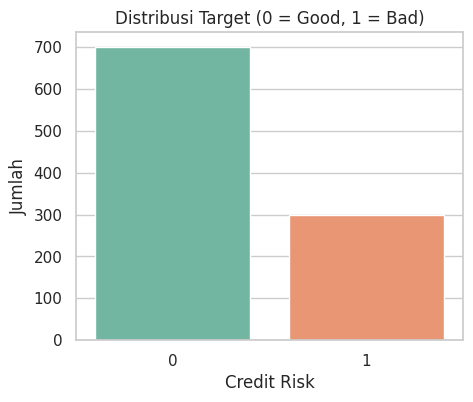

credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64


In [7]:
# 4.3 Distribusi target (credit_risk)
plt.figure(figsize=(5,4))
sns.countplot(x="credit_risk", data=df, palette="Set2")
plt.title("Distribusi Target (0 = Good, 1 = Bad)")
plt.xlabel("Credit Risk")
plt.ylabel("Jumlah")
plt.show()

print(df["credit_risk"].value_counts(normalize=True) * 100)

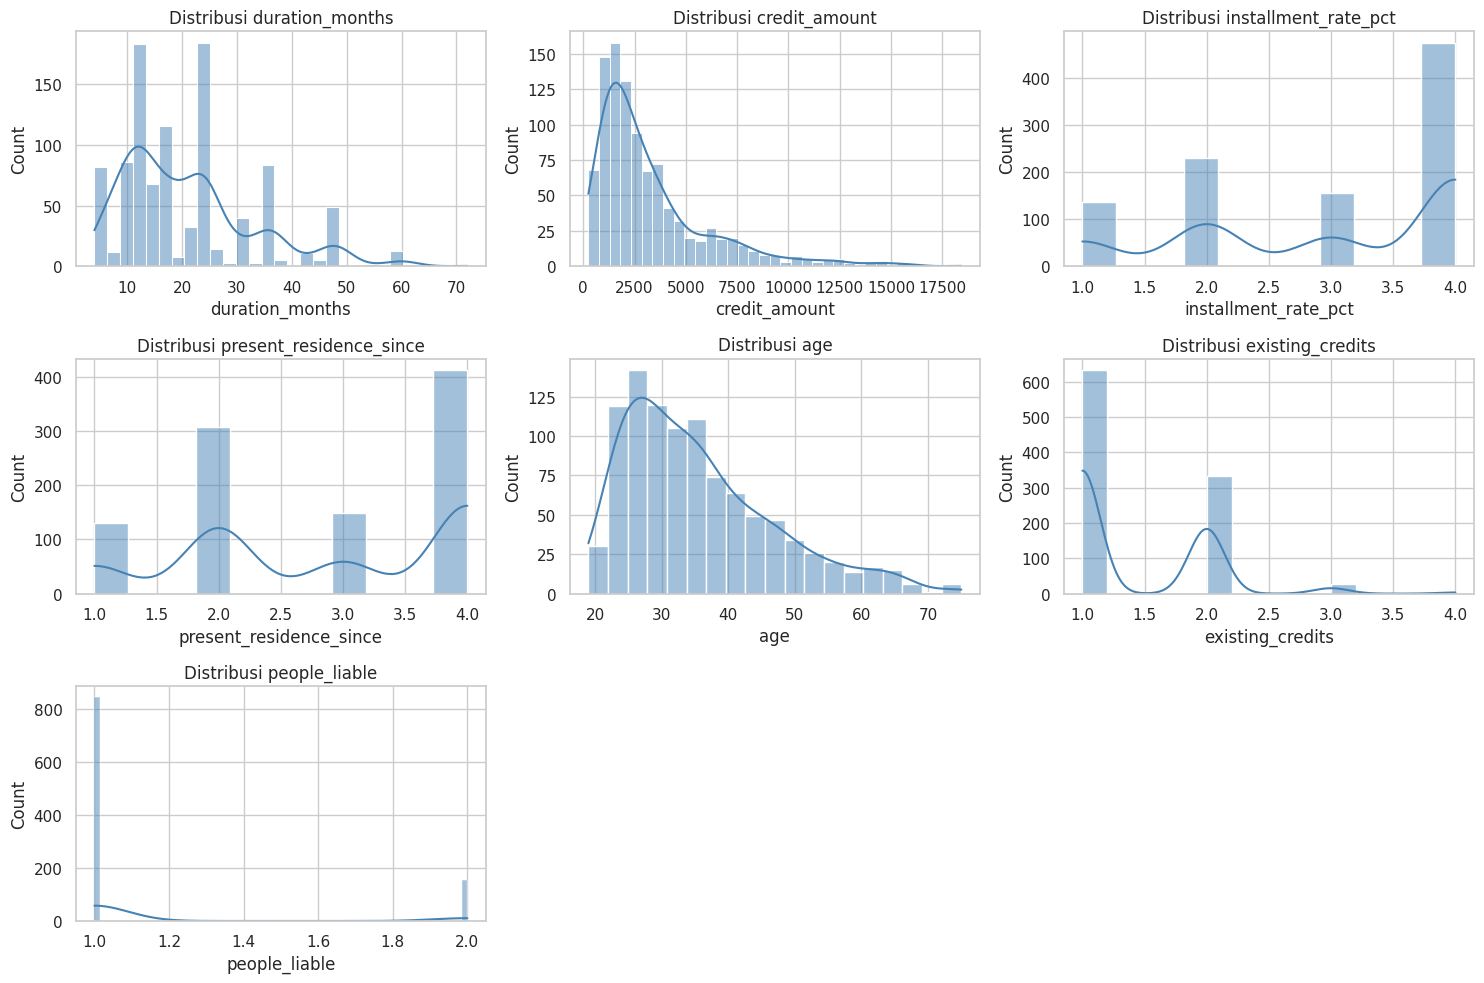

In [8]:
# 4.4 Distribusi fitur numerik
numerical_cols = ["duration_months", "credit_amount", "installment_rate_pct",
                   "present_residence_since", "age", "existing_credits", "people_liable"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribusi {col}")
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

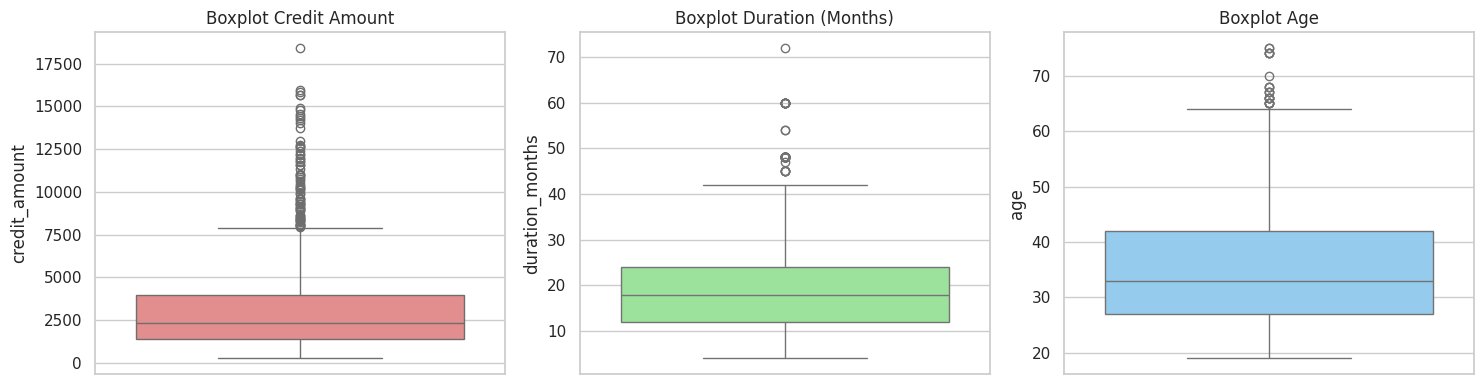

In [9]:
# 4.5 Mendeteksi outlier menggunakan boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df["credit_amount"], ax=axes[0], color="lightcoral")
axes[0].set_title("Boxplot Credit Amount")

sns.boxplot(y=df["duration_months"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot Duration (Months)")

sns.boxplot(y=df["age"], ax=axes[2], color="lightskyblue")
axes[2].set_title("Boxplot Age")
plt.tight_layout()
plt.show()

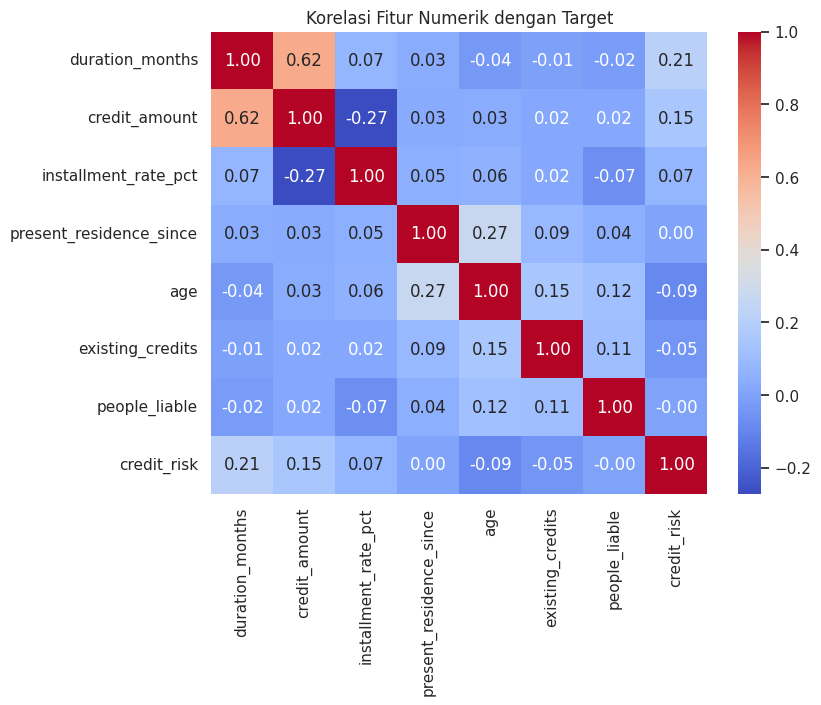

In [10]:
# 4.6 Korelasi antar fitur numerik dengan target
corr_df = df[numerical_cols + ["credit_risk"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Fitur Numerik dengan Target")
plt.show()

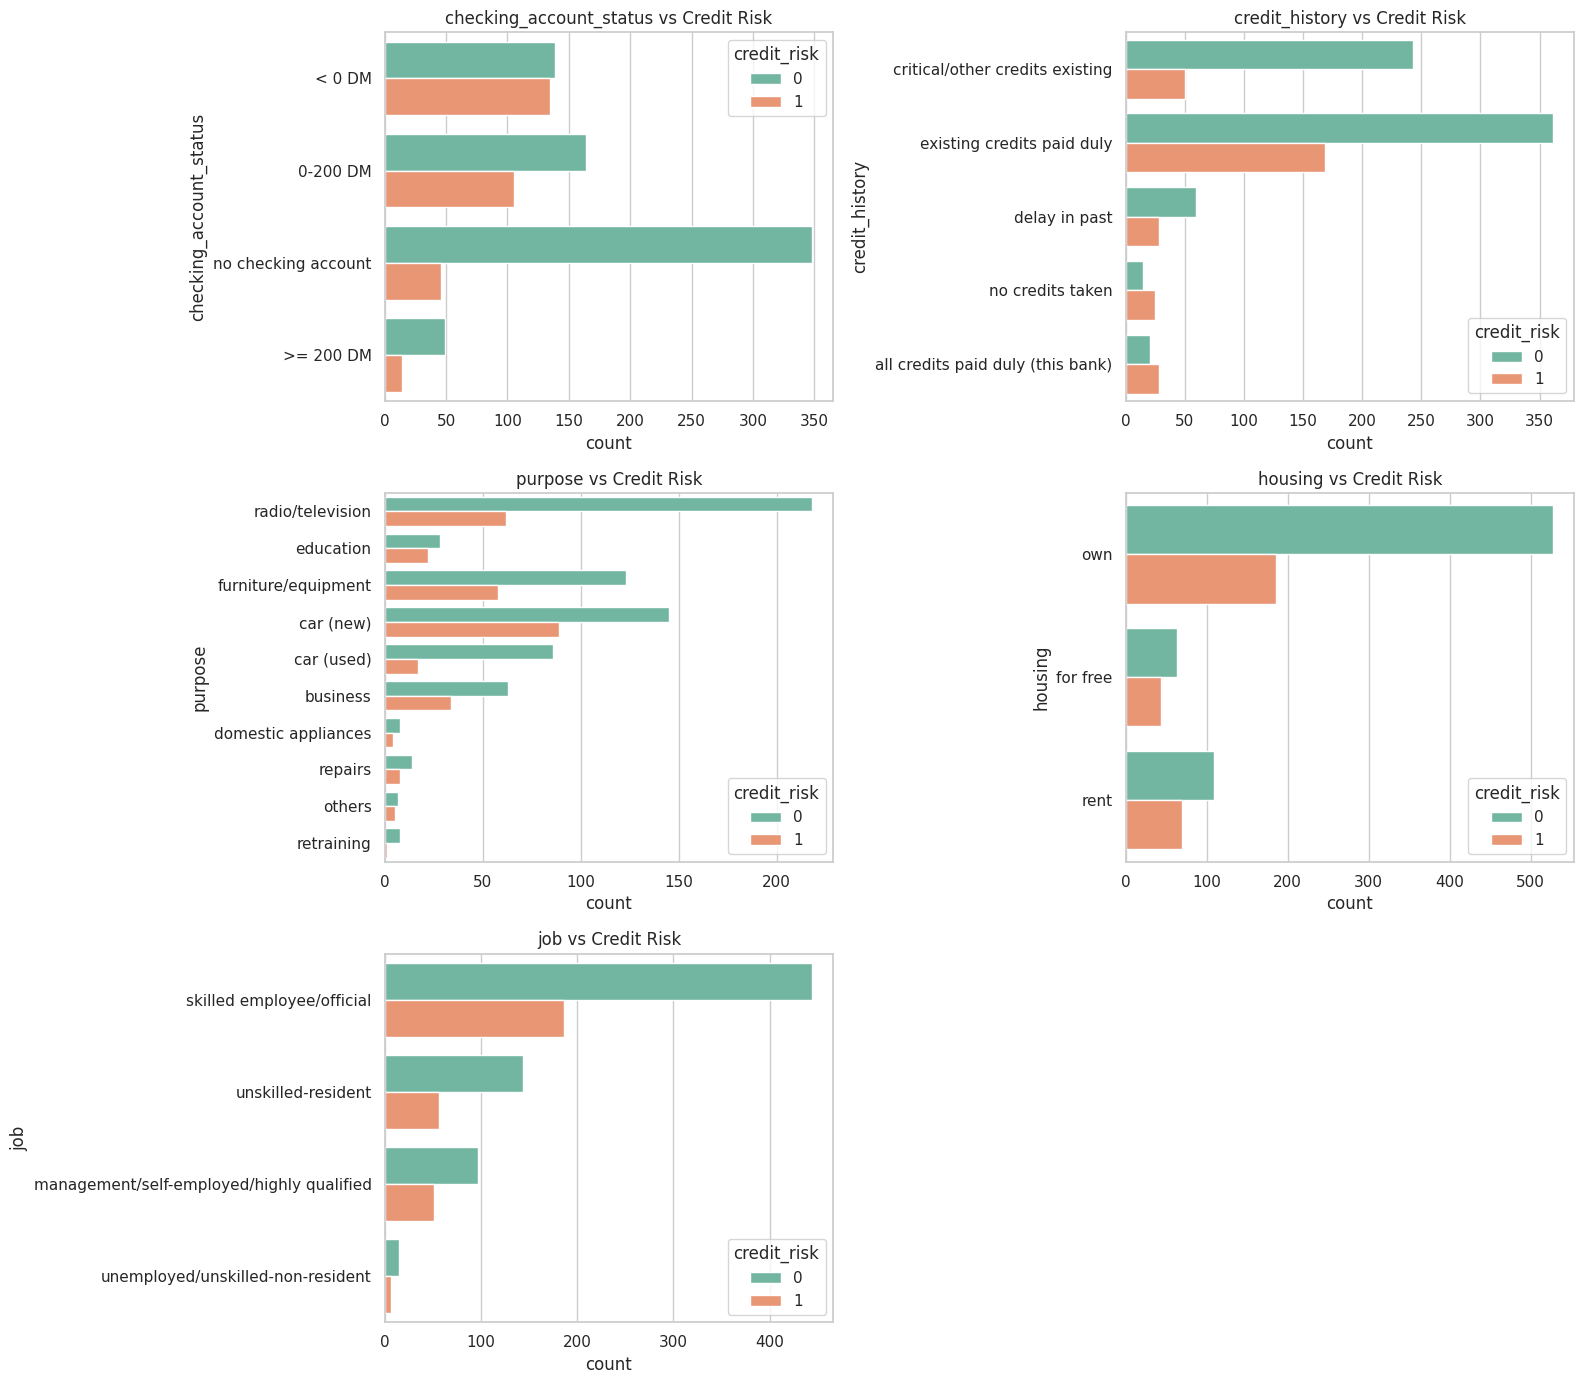

In [11]:
# 4.7 Hubungan beberapa fitur kategorikal dengan target
categorical_cols = ["checking_account_status", "credit_history", "purpose", "housing", "job"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, y=col, hue="credit_risk", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Credit Risk")
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Insight dari hasil EDA:**- Dataset tidak memiliki missing values maupun baris duplikat.- Target bersifat tidak seimbang (imbalanced), proporsi kredit *Good* (~70%) jauh lebih banyak dibandingkan *Bad* (~30%).- Fitur `credit_amount` dan `duration_months` memiliki distribusi yang miring ke kanan (right-skewed) serta mengandung beberapa outlier.- `checking_account_status` dan `credit_history` terlihat memiliki pola yang cukup jelas terhadap target, sehingga berpotensi menjadi fitur penting dalam pemodelan.

# **5. Data Preprocessing**Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:1. Menghapus atau Menangani Data Kosong (Missing Values)2. Menghapus Data Duplikat3. Normalisasi atau Standarisasi Fitur4. Deteksi dan Penanganan Outlier5. Encoding Data Kategorikal6. Binning (Pengelompokan Data)Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# 5.1 Menangani missing values dan data duplikat (sebagai antisipasi, walau hasil EDA = 0)
df_clean = df.copy()
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

print("Ukuran dataset setelah pembersihan:", df_clean.shape)

Ukuran dataset setelah pembersihan: (1000, 21)


In [13]:
# 5.2 Encoding fitur kategorikal menggunakan Label Encoding
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()
print("Fitur kategorikal yang akan di-encode:", categorical_features)

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

df_clean.head()

Fitur kategorikal yang akan di-encode: ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,6,1,7,1169,4,3,4,3,2,4,2,67,1,1,2,1,1,1,1,0
1,0,48,3,7,5951,2,0,2,0,2,2,2,22,1,1,1,1,1,0,1,1
2,3,12,1,4,2096,2,1,2,3,2,3,2,49,1,1,1,3,2,0,1,0
3,1,42,3,5,7882,2,1,2,3,1,4,0,45,1,0,1,1,2,0,1,0
4,1,24,2,1,4870,2,0,3,3,2,4,3,53,1,0,2,1,2,0,1,1


In [14]:
# 5.3 Penanganan outlier pada fitur numerik menggunakan metode IQR (capping)
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

for col in ["credit_amount", "duration_months", "age"]:
    df_clean = cap_outliers_iqr(df_clean, col)

print("Outlier pada credit_amount, duration_months, dan age telah ditangani (capping IQR).")

Outlier pada credit_amount, duration_months, dan age telah ditangani (capping IQR).


In [15]:
# 5.4 Pemisahan fitur (X) dan target (y)
X = df_clean.drop(columns=["credit_risk"])
y = df_clean["credit_risk"]

# 5.5 Split data menjadi data latih dan data uji (80:20), stratify agar proporsi target tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5.6 Standarisasi fitur numerik menggunakan StandardScaler
numerical_features = numerical_cols
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
X_train.head()

Ukuran X_train: (800, 20)
Ukuran X_test : (200, 20)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker
828,1,1.494889,3,2,2.241785,4,3,0.052281,3,2,1.053413,3,1.088219,1,0,-0.718745,1,-0.436436,0,1
997,3,-0.782495,3,7,-1.019124,2,3,0.942164,3,2,1.053413,1,0.255044,1,1,-0.718745,1,-0.436436,0,1
148,1,1.494889,1,5,1.084829,2,0,0.052281,3,1,-0.747293,0,-0.670706,1,1,1.045047,1,-0.436436,0,1
735,0,1.494889,0,3,0.448622,4,2,0.052281,0,2,-0.747293,3,-0.578131,0,1,-0.718745,2,-0.436436,0,1
130,0,2.064234,3,1,2.241785,4,1,-1.727486,0,2,-0.747293,1,-1.041006,1,1,-0.718745,1,-0.436436,0,1


In [16]:
# 5.7 Menyimpan hasil preprocessing ke dalam file CSV
# Hasil ini akan digunakan pada tahap Membangun Model (Kriteria 2)
train_df = X_train.copy()
train_df["credit_risk"] = y_train.values

test_df = X_test.copy()
test_df["credit_risk"] = y_test.values

train_df.to_csv("german_credit_data_preprocessing_train.csv", index=False)
test_df.to_csv("german_credit_data_preprocessing_test.csv", index=False)

print("File hasil preprocessing berhasil disimpan:")
print("- german_credit_data_preprocessing_train.csv")
print("- german_credit_data_preprocessing_test.csv")

File hasil preprocessing berhasil disimpan:
- german_credit_data_preprocessing_train.csv
- german_credit_data_preprocessing_test.csv
